# 문항1. 핵심 키워드 추출

### 0. 사이트에서 뉴스기사를 하나 선택하여 전처리를 수행하세요.

### 1. TextRank 구현

전처리 된 텍스트 데이터를 사용하여 TextRank 알고리즘을 구현하고, 핵심 키워드를 추출해보세요.

TextRank 알고리즘의 기본적인 원리에 대해 설명해보세요. (PageRank와의 유사점과 차이점을 기반으로 생각해보세요.)

### 2. 시각화

적절한 그래프를 활용하여, 중요도가 높은 순으로 상위 10개 키워드를 시각화 해보세요.

키워드의 중요도를 표현하기 위해 어떤 그래프를 사용했고 그 이유는 무엇인가요?



0. 전처리 수행

In [2]:
%pip install beautifulsoup4
%pip install requests

^C
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
from bs4 import BeautifulSoup

In [4]:
url = 'https://n.news.naver.com/article/661/0000083945?cds=news_media_pc&type=editn'
response = requests.get(url)
soup = BeautifulSoup(response.text,'html.parser')

In [5]:
kor_news = soup.select_one('#newsct_article')
kor_text = kor_news.get_text(strip=True)
print(kor_text)

연휴 닷새 내국인 17만 399명… 예상보다 2만 1,501명 적어국내선 38편·좌석 1만 5,449석 감소… 항공 공급 축소 이어져짧은 연휴에 일본 등 근거리 해외여행 수요… 제주와 경쟁 심화외국인은 15.3% 증가… 내·외국인 관광시장 흐름 엇갈려제주행 국내선 공급 감소와 근거리 해외여행 수요 흐름을 표현한 이미지. (AI 생성)추석 연휴에도 제주를 찾는 내국인 관광객 감소 흐름은 꺾이지 않았습니다.지난 23일부터 27일까지 닷새 동안 제주를 찾은 내국인은 17만 399명으로 잠정 집계됐습니다. 연휴 전 예상했던 19만 1,900명보다 2만 1,501명, 11.2% 적었습니다.추석이 포함된 9월 전체로 보면 내국인 관광객은 지난해 같은 기간보다 9.3% 줄었습니다.제주행 국내선 공급이 감소한 가운데 일본 등 가까운 해외로 향하는 여행 수요가 이어지면서 제주 내국인 관광시장의 부담도 커지는 모습입니다.■ 예상보다 내국인 2만 1,501명 적어28일 제주도관광협회 일일 관광객 입도현황에 따르면 지난 23일부터 27일까지 제주를 찾은 관광객은 모두 21만 2,503명으로 잠정 집계됐습니다.당초 예상했던 22만 9,000명보다 1만 6,497명, 7.2% 적습니다.이 기간 내국인은 닷새 동안 17만 399명이 제주를 찾았습니다.반면 외국인은 4만 2,104명으로 예상치보다 5,004명 많았습니다.외국인 입도객이 전망치를 웃돌았지만 내국인에서 더 큰 차이가 발생하면서 전체 관광객도 당초 예상에 미치지 못했습니다.■ 국내선 38편·좌석 1만 5,449석 줄어제주를 오가는 국내선 공급도 감소했습니다.이번 추석 연휴 국내선 운항계획은 1,105편으로 지난해보다 38편, 3.3% 줄었습니다. 공급좌석은 20만 8,865석으로 1만 5,449석, 6.9% 감소했습니다.국제선은 지난해보다 25편 늘어난 184편이 편성됐고 공급좌석도 14.8% 증가했습니다.연휴에만 국한된 흐름도 아닙니다.9월 김포~제주 노선 예정 공급좌석은 양방향 108만 4,920석으로 지난해 같은 달보다 

In [6]:
%pip install konlpy

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Okt 토큰화
from konlpy.tag import Okt
okt= Okt()
okt_tokens = okt.morphs(kor_text)
print(okt_tokens)

# Okt 품사 태깅
oktTag = []
for token in okt_tokens:
    oktTag += okt.pos(token)
print(oktTag)

['연휴', '닷새', '내', '국', '인', '17만', '399', '명', '…', '예상', '보다', '2만', '1,501', '명', '적어', '국내선', '38', '편', '·', '좌석', '1만', '5,449', '석', '감소', '…', '항공', '공급', '축소', '이어져', '짧은', '연휴', '에', '일본', '등', '근거리', '해외여행', '수요', '…', '제주', '와', '경쟁', '심화', '외국인', '은', '15.3%', '증가', '…', '내', '·', '외국인', '관광', '시장', '흐름', '엇갈려', '제', '주행', '국내선', '공급', '감소', '와', '근거리', '해외여행', '수요', '흐름', '을', '표현', '한', '이미지', '.', '(', 'AI', '생', '성', ')', '추석', '연휴', '에도', '제주', '를', '찾는', '내', '국', '인', '관광객', '감소', '흐름', '은', '꺾이지', '않았습니다', '.', '지난', '23일', '부터', '27일', '까지', '닷새', '동안', '제주', '를', '찾은', '내', '국', '인', '은', '17만', '399', '명', '으로', '잠정', '집계', '됐습니다', '.', '연휴', '전', '예상', '했던', '19만', '1,900', '명보', '다', '2만', '1,501', '명', ',', '11.2%', '적었습니다', '.', '추석', '이', '포함', '된', '9월', '전체', '로', '보면', '내', '국', '인', '관광객', '은', '지난해', '같은', '기간', '보다', '9.3%', '줄었습니다', '.', '제', '주행', '국내선', '공급', '이', '감소', '한', '가운데', '일본', '등', '가까운', '해외', '로', '향', '하는', '여행', '수요', '가', '이어지면서', '제

In [8]:
# stemming (어간 추출)

korean_stemmed = okt.morphs(kor_text, stem=True)
print("--- 한글 어간 추출 결과 ---")
print(korean_stemmed)

# Lemmatization (표제어 추출)

korean_lemmatized = okt.pos(kor_text, stem=True)
print("\n--- 한글 표제어 추출 결과 (품사 보존) ---")
print(korean_lemmatized)

--- 한글 어간 추출 결과 ---
['연휴', '닷새', '내', '국', '인', '17만', '399', '명', '…', '예상', '보다', '2만', '1,501', '명', '적다', '국내선', '38', '편', '·', '좌석', '1만', '5,449', '석', '감소', '…', '항공', '공급', '축소', '이어지다', '짧다', '연휴', '에', '일본', '등', '근거리', '해외여행', '수요', '…', '제주', '와', '경쟁', '심화', '외국인', '은', '15.3%', '증가', '…', '내', '·', '외국인', '관광', '시장', '흐름', '엇갈리다', '제', '주행', '국내선', '공급', '감소', '와', '근거리', '해외여행', '수요', '흐름', '을', '표현', '한', '이미지', '.', '(', 'AI', '생', '성', ')', '추석', '연휴', '에도', '제주', '를', '찾다', '내', '국', '인', '관광객', '감소', '흐름', '은', '꺾다', '않다', '.', '지난', '23일', '부터', '27일', '까지', '닷새', '동안', '제주', '를', '찾다', '내', '국', '인', '은', '17만', '399', '명', '으로', '잠정', '집계', '돼다', '.', '연휴', '전', '예상', '하다', '19만', '1,900', '명보', '다', '2만', '1,501', '명', ',', '11.2%', '적다', '.', '추석', '이', '포함', '되다', '9월', '전체', '로', '보다', '내', '국', '인', '관광객', '은', '지난해', '같다', '기간', '보다', '9.3%', '줄다', '.', '제', '주행', '국내선', '공급', '이', '감소', '한', '가운데', '일본', '등', '가깝다', '해외', '로', '향', '하다', '여행', '수요', '가', 

In [9]:
# 불용어 처리

stopPos = ['Suffix','Punctuation','Josa','Foreign','Alpha','Number']

stopWord = [
    '.', ',', '…', '·', '■', '↓', '“', '”', '~', '(', ')',
    '명', '은', '내', '를', '이', '국', '인', '으로', '보다', '가',
    '했습니다', '등', '도', '석', '에', '을', '편', '와', '까지', 
    '로', '계', '제', '한', '된', '는', '에는', '에서는', '의', '고', '지',
    '하는', '하고', '있습니다', '같은', '찾은', '됐습니다', '줄었습니다', '기록', '했구'
]

word = []
for tag in oktTag:
    if tag[1] not in stopPos:
        if tag[0] not in stopWord and len(tag[0])>1 :
            word.append(tag[0])

print(word)

['연휴', '닷새', '예상', '적어', '국내선', '좌석', '감소', '항공', '공급', '축소', '이어져', '짧은', '연휴', '일본', '근거리', '해외여행', '수요', '제주', '경쟁', '심화', '외국인', '증가', '외국인', '관광', '시장', '흐름', '엇갈려', '주행', '국내선', '공급', '감소', '근거리', '해외여행', '수요', '흐름', '표현', '이미지', '추석', '연휴', '제주', '찾는', '관광객', '감소', '흐름', '꺾이지', '않았습니다', '지난', '부터', '닷새', '동안', '제주', '잠정', '집계', '연휴', '예상', '했던', '명보', '적었습니다', '추석', '포함', '전체', '보면', '관광객', '지난해', '기간', '주행', '국내선', '공급', '감소', '가운데', '일본', '가까운', '해외', '여행', '수요', '이어지면서', '제주', '관광', '시장', '부담', '커지는', '모습', '입니다', '예상', '적어', '제주도', '관광', '협회', '일일', '관광객', '입도', '현황', '따르면', '지난', '부터', '제주', '관광객', '모두', '잠정', '집계', '당초', '예상', '했던', '명보', '적습니다', '기간', '닷새', '동안', '제주', '찾았습니다', '반면', '외국인', '상치', '많았습니다', '외국인', '입도', '망치', '돌았지만', '차이', '발생', '하면서', '전체', '관광객', '당초', '예상', '미치지', '국내선', '좌석', '줄어', '제주', '오가는', '국내선', '공급', '감소', '이번', '추석', '연휴', '국내선', '운항', '계획', '지난해', '공급', '좌석', '감소', '국제선', '지난해', '늘어난', '편이', '편성', '됐고', '공급', '좌석', '증가', '연휴', '국한', '흐름', '아닙니다

1. text rank

In [11]:
doc = ' '.join(word)

tokens = doc.split()
unique_tokens = set(tokens)
word2idx = {t: i for i, t in enumerate(unique_tokens)}

print(tokens)
print(word2idx)

['연휴', '닷새', '예상', '적어', '국내선', '좌석', '감소', '항공', '공급', '축소', '이어져', '짧은', '연휴', '일본', '근거리', '해외여행', '수요', '제주', '경쟁', '심화', '외국인', '증가', '외국인', '관광', '시장', '흐름', '엇갈려', '주행', '국내선', '공급', '감소', '근거리', '해외여행', '수요', '흐름', '표현', '이미지', '추석', '연휴', '제주', '찾는', '관광객', '감소', '흐름', '꺾이지', '않았습니다', '지난', '부터', '닷새', '동안', '제주', '잠정', '집계', '연휴', '예상', '했던', '명보', '적었습니다', '추석', '포함', '전체', '보면', '관광객', '지난해', '기간', '주행', '국내선', '공급', '감소', '가운데', '일본', '가까운', '해외', '여행', '수요', '이어지면서', '제주', '관광', '시장', '부담', '커지는', '모습', '입니다', '예상', '적어', '제주도', '관광', '협회', '일일', '관광객', '입도', '현황', '따르면', '지난', '부터', '제주', '관광객', '모두', '잠정', '집계', '당초', '예상', '했던', '명보', '적습니다', '기간', '닷새', '동안', '제주', '찾았습니다', '반면', '외국인', '상치', '많았습니다', '외국인', '입도', '망치', '돌았지만', '차이', '발생', '하면서', '전체', '관광객', '당초', '예상', '미치지', '국내선', '좌석', '줄어', '제주', '오가는', '국내선', '공급', '감소', '이번', '추석', '연휴', '국내선', '운항', '계획', '지난해', '공급', '좌석', '감소', '국제선', '지난해', '늘어난', '편이', '편성', '됐고', '공급', '좌석', '증가', '연휴', '국한', '흐름', '아닙니다

In [12]:
import numpy as np

weighted_edges = np.eye(len(word2idx)) * 0

window_size = 3

for i in range(len(tokens) - window_size + 1):
    
    temp = tokens[i:i+window_size]

    for ti, token1 in enumerate(temp):
        for token2 in temp[ti+1:]:
            
            idx_1 = word2idx[token1]
            idx_2 = word2idx[token2]
            
            weighted_edges[idx_1, idx_2] = 1
            weighted_edges[idx_2, idx_1] = 1

weighted_edges


nodes = np.ones(len(word2idx))
weighted_edges /= weighted_edges.sum(axis=1).reshape(-1, 1)

nodes, weighted_edges

(array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.

In [14]:
edges = nodes.reshape(-1, 1) * weighted_edges

damping_factor = 0.85

scores = (1 - damping_factor) + damping_factor * edges.sum(axis=0)

scores

array([0.37970238, 0.85833333, 0.8215    , 0.73482906, 1.39221429,
       6.23433205, 0.46733333, 0.82291667, 3.08989223, 1.89066983,
       0.89375   , 1.53465368, 0.71525   , 0.47383248, 0.84416667,
       0.53101744, 0.52440476, 0.52035714, 0.67902098, 0.54614837,
       0.7875    , 0.85833333, 0.63823171, 1.70278193, 0.98040757,
       0.54786255, 0.85480574, 0.67619048, 1.30126095, 0.694     ,
       0.6397619 , 3.09729237, 1.65104113, 0.66607143, 0.51895604,
       0.87468987, 0.53084416, 0.89375   , 0.95626732, 0.85855128,
       1.51093831, 3.01692857, 0.73482906, 0.45674363, 0.73184524,
       1.56084684, 1.86465603, 0.67300443, 0.86477273, 0.38165873,
       1.85804335, 1.22778299, 0.85833333, 0.73184524, 0.40447925,
       0.6146978 , 0.73791667, 2.32608885, 0.46935714, 1.97204537,
       0.70576923, 0.46887319, 0.66656504, 0.68627273, 0.49607143,
       1.31043398, 0.5569697 , 0.4885989 , 0.50686807, 0.25762987,
       0.33686561, 0.8215    , 3.52186591, 0.71988636, 0.25949

In [15]:
idx2word = {i: t for t, i in word2idx.items()}

[idx2word[idx] for idx in scores.argsort()[::-1]]   # 중요 단어 순서대로 도출

['제주',
 '연휴',
 '수요',
 '외국인',
 '추석',
 '감소',
 '전체',
 '지난해',
 '흐름',
 '국내선',
 '관광객',
 '공급',
 '좌석',
 '예약',
 '예전',
 '여행',
 '포함',
 '입도',
 '관광',
 '부담',
 '예상',
 '기간',
 '해외여행',
 '짧은',
 '일본',
 '주행',
 '증가',
 '지난',
 '해외',
 '지역',
 '편이',
 '항공',
 '노선',
 '실제',
 '올해',
 '가까운',
 '시장',
 '목적지',
 '반면',
 '많았습니다',
 '차이',
 '나옵니다',
 '주요',
 '뱃길',
 '차량',
 '닷새',
 '늘었습니다',
 '부터',
 '했던',
 '당초',
 '특정',
 '했고',
 '적어',
 '나흘',
 '명보',
 '소진',
 '출발',
 '오사카',
 '선적',
 '빠르게',
 '여객',
 '어려워졌다는',
 '돌았지만',
 '의견',
 '업계',
 '쉽지',
 '선택',
 '판매',
 '잠정',
 '후쿠오카',
 '발생',
 '사이',
 '수준',
 '이어졌지만',
 '하루',
 '보였습니다',
 '항공권',
 '만석',
 '동안',
 '입니다',
 '운항',
 '도쿄',
 '그치면서',
 '커지는',
 '차이는',
 '넘게',
 '줄어든',
 '시간',
 '편성',
 '늘어난',
 '날짜',
 '집계',
 '모습',
 '수기',
 '분명하게',
 '관광업',
 '있지만',
 '망치',
 '않은',
 '데이터',
 '협회',
 '하기가',
 '주말',
 '전인',
 '관계자',
 '많았지만',
 '가격',
 '앞두고',
 '상품',
 '하면서',
 '되는',
 '가량',
 '상황',
 '돌고',
 '강세',
 '따르면',
 '나타난',
 '파악',
 '아닙니다',
 '첫날',
 '커지면서',
 '드러났습니다',
 '생각',
 '먼저',
 '제주도',
 '않았습니다',
 '급량',
 '트립',
 '축소',
 '적습니다',
 '현황',
 '끌어',
 '됐고',
 '

[TextRank 알고리즘의 기본 원리]

- TextRank는 구글의 웹 페이지 랭킹 알고리즘인 PageRank를 텍스트 데이터에 맞게 변형한 비지도 학습(Unsupervised Learning) 기반의 그래프 모델
- 기본적인 핵심 아이디어는 "중요한 노드(단어/문장)에게 투표(연결)를 많이 받은 노드가 중요하다"라는 재귀적(Recursive)인 구조

- 핵심 키워드 추출 동작 과정
    1. 노드(Vertex) 구성: 문서 전처리 과정을 거쳐 명사(NNG, NNP)나 영문 약어(SL) 같은 의미를 가진 단어들을 그래프의 노드로 등록
    2. 엣지(Edge) 및 가중치(Weight) 설정: 특정 크기의 창(Sliding Window)을 설정하여, 하나의 창 안에서 두 단어가 동시에 등장(Co-occurrence)하면 노드 사이를 선(Edge)으로 연결합니다. 이때 창 안에서 같이 등장한 횟수가 많을수록 선의 굵기(가중치)가 무거워짐
    3. 스코어 수렴(Iterative 수렴): 모든 단어 노드의 점수를 1로 초기화한 후, 각자 가진 점수를 연결된 이웃 단어들에게 나눠주고 다시 받는 과정을 값이 변하지 않을 때까지 반복 계산
    4. 랭킹: 최종 수렴된 점수가 가장 높은 단어 순으로 정렬하여 문서의 핵심 키워드를 추출


[PageRank와의 유사점과 차이점]

- 유사점
    1. 그래프 기반 랭킹: 두 알고리즘 모두 개별 요소들의 독립적인 빈도가 아니라, 전체 구조 안에서 노드 간의 연결 관계(네트워크 구조)를 분석 
    2. 수식과 댐핑(Damping Factor): 점수를 분배하는 수식구조가 본질적으로 동일. 
    3. 비지도 학습(Unsupervised): 사전에 정답이 태깅된 학습 데이터나 라벨이 전혀 필요 없으며, 텍스트(혹은 웹페이지 링크) 자체의 링크 구조만 있으면 계산이 가능

- 차이점
    1. 무방향 그래프 : 하나의 윈도우 안에 같이 나오면 상호 연결.
    2. 엣지 가중치 : 동시 등장 빈도가 가중치가 됨.
    3. 그래프 크기 및 희소성 : 단어 또는 문장 기준이므로 단일 문서 기준, 페이지랭크보다 촘촘하게 짜여있음


2. 시각화

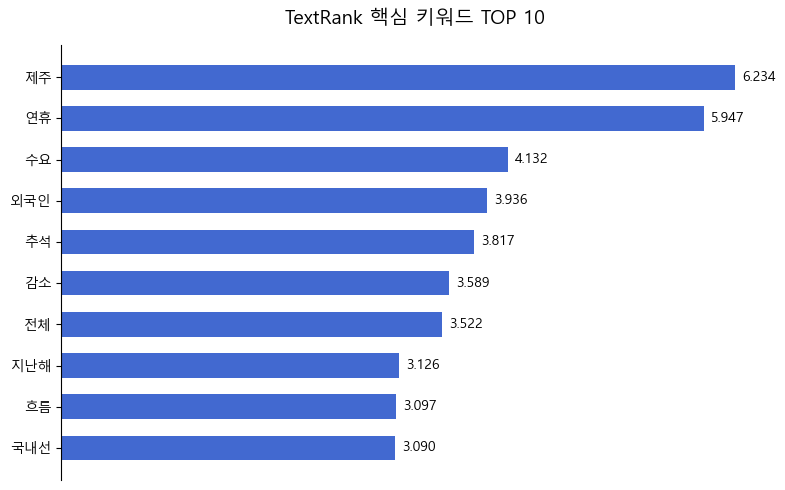

In [20]:
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 


word_scores = {idx2word[i]: scores[i] for i in range(len(scores))}
top10_data = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:10]


top10_data = top10_data[::-1]
top10_words = [x[0] for x in top10_data]
top10_scores = [x[1] for x in top10_data]

# 가로 막대그래프 출력
plt.figure(figsize=(8, 5))
bars = plt.barh(top10_words, top10_scores, color="#4269D0", height=0.6)

# 막대 끝에 점수 표시 (소수점 3자리까지 깔끔하게)
plt.bar_label(bars, padding=5, fmt="%.3f") 

plt.title("TextRank 핵심 키워드 TOP 10", fontsize=14, pad=15)
plt.gca().xaxis.set_visible(False)


for s in ["top", "right", "bottom"]:
    plt.gca().spines[s].set_visible(False)

plt.tight_layout()
plt.show()

[ 가로막대 그래프 사용 이유 ]

- 정확한 수치 및 순위 비교: TextRank 알고리즘을 통해 수치화된 점수(중요도)를 왜곡 없이 보여줄 수 있으며, 점수가 가장 높은 핵심 키워드부터 위에서 아래로 순서대로 배치되어 문서의 주제를 관통하는 핵심어의 순위를 직관적으로 파악할 수 있기 때문입니다.


# 문항2 : 문서 요약

## 1. Luhn Summarizer 구현

Luhn Summarizer를 구현하여 문서를 요약해보세요.

중요 키워드를 선택하는 a, b값을 바꿔가면서 문서 요약 결과를 확인해보세요.

## 2. TextRank 구현

위에서 전처리한 텍스트 데이터를 활용하여 TextRank를 구현하고, 문서를 요약해보세요.

TextRank를 문서 요약에 적용할 때의 장점을 다음의 두 가지 관점에서 설명해보세요.

영어 뉴스를 수집하여 동일하게 수행해보세요.

10개의 비슷한 뉴스기사를 하나로 합쳐서 수행해보세요. 100개, 1000개는 어떨까요?

1. luhn summarizer 구현

In [21]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\KWON
[nltk_data]     OHRYUN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
url = 'https://n.news.naver.com/article/661/0000083945?cds=news_media_pc&type=editn'
response = requests.get(url)
soup = BeautifulSoup(response.text,'html.parser')

In [31]:
kor_news = soup.select_one('#newsct_article')
doc = kor_news.get_text(strip=True)
print(doc)

연휴 닷새 내국인 17만 399명… 예상보다 2만 1,501명 적어국내선 38편·좌석 1만 5,449석 감소… 항공 공급 축소 이어져짧은 연휴에 일본 등 근거리 해외여행 수요… 제주와 경쟁 심화외국인은 15.3% 증가… 내·외국인 관광시장 흐름 엇갈려제주행 국내선 공급 감소와 근거리 해외여행 수요 흐름을 표현한 이미지. (AI 생성)추석 연휴에도 제주를 찾는 내국인 관광객 감소 흐름은 꺾이지 않았습니다.지난 23일부터 27일까지 닷새 동안 제주를 찾은 내국인은 17만 399명으로 잠정 집계됐습니다. 연휴 전 예상했던 19만 1,900명보다 2만 1,501명, 11.2% 적었습니다.추석이 포함된 9월 전체로 보면 내국인 관광객은 지난해 같은 기간보다 9.3% 줄었습니다.제주행 국내선 공급이 감소한 가운데 일본 등 가까운 해외로 향하는 여행 수요가 이어지면서 제주 내국인 관광시장의 부담도 커지는 모습입니다.■ 예상보다 내국인 2만 1,501명 적어28일 제주도관광협회 일일 관광객 입도현황에 따르면 지난 23일부터 27일까지 제주를 찾은 관광객은 모두 21만 2,503명으로 잠정 집계됐습니다.당초 예상했던 22만 9,000명보다 1만 6,497명, 7.2% 적습니다.이 기간 내국인은 닷새 동안 17만 399명이 제주를 찾았습니다.반면 외국인은 4만 2,104명으로 예상치보다 5,004명 많았습니다.외국인 입도객이 전망치를 웃돌았지만 내국인에서 더 큰 차이가 발생하면서 전체 관광객도 당초 예상에 미치지 못했습니다.■ 국내선 38편·좌석 1만 5,449석 줄어제주를 오가는 국내선 공급도 감소했습니다.이번 추석 연휴 국내선 운항계획은 1,105편으로 지난해보다 38편, 3.3% 줄었습니다. 공급좌석은 20만 8,865석으로 1만 5,449석, 6.9% 감소했습니다.국제선은 지난해보다 25편 늘어난 184편이 편성됐고 공급좌석도 14.8% 증가했습니다.연휴에만 국한된 흐름도 아닙니다.9월 김포~제주 노선 예정 공급좌석은 양방향 108만 4,920석으로 지난해 같은 달보다 

In [32]:
from nltk.tokenize import sent_tokenize
# from konlpy.tag import Mecab
from konlpy.tag import Komoran

# 문장 분리
def get_sentences(txt):
    return sent_tokenize(txt) 

komoran = Komoran() 

# 토큰화 
def get_words(txt):
    # mecab = Mecab()
    return [t[0] for t in komoran.pos(txt) if (t[1][0] == 'N') & (len(t[0])>1)]

In [39]:
# 중요 단어 결정
def get_keywords(word_list, min_ratio=0.01, max_ratio=0.5) :     
    assert (min_ratio < 1 and max_ratio < 1)
    
    total = len(word_list)   

    keywords = set()

    for token in set(word_list):
        freq = word_list.count(token) / total  
        if min_ratio < freq < max_ratio:  
            keywords.add(token)  

    return keywords

In [34]:
# 문장의 가중치 계산
def get_sentence_weight(sentence, keywords):
    tokens = get_words(sentence)
    window_start = 0; window_end = -1
    
    
    for i, token in enumerate(tokens):
        if token in keywords:
            window_start = i
            break

    
    for i, token in enumerate(tokens):
        if token in keywords:
            window_end = i
    
    
    if window_start > window_end:
        return 0
    
    
    window_size = window_end - window_start + 1

    
    token_count = 0
    for token in tokens[window_start:window_end+1]:
        token_count += token in keywords

    
    return token_count**2 / window_size

In [35]:
# 문서 요약
def summarize(content, max_no_of_sentences = 10):
    sentences = get_sentences(content)
    
    result = []
    for sentence in sentences:
        tokens = get_words(sentence)
        keywords = get_keywords(tokens)
        sentence_weight = get_sentence_weight(sentence, keywords)
        result.append( (sentence, sentence_weight) )
        
    return sorted(result, key=lambda x: -x[1])[:max_no_of_sentences]

In [40]:
li = summarize (doc ,  3)
for s in li :
    print(s)

('제주공항 국내선 전체를 봐도 올해 하계 운항기간 공급계획이 지난해 실제 공급량보다 약 65만 석 줄었습니다.지역 관광업계에서도 추석을 겨냥한 제주여행 상품 판매는 이어졌지만, 9월 평수기에는 국내선 항공 공급 감소와 항공권 가격 부담 등으로 내국인 여행 수요가 위축되는 흐름이 나타난 것으로 파악됐습니다.연휴를 앞두고 일부 제주행 항공편이 만석을 기록했고, 주요 뱃길에서도 차량 선적과 여객 예약이 빠르게 소진됐습니다.특정 날짜와 노선에 수요가 몰렸지만 연휴 전체 내국인 입도객을 끌어올리지는 못했습니다.■ 짧은 연휴에 일본 등 근거리 해외로같은 기간 해외여행 수요는 일본 등 가까운 지역으로 향했습니다.올해 추석 공식 연휴가 주말을 포함해 나흘에 그치면서 이동시간이 짧은 해외 목적지가 강세를 보였습니다.실제 트립닷컴의 추석 예약 데이터에서는 오사카와 후쿠오카, 도쿄가 해외여행 목적지 1~3위를 차지했습니다.', 86.0)
('연휴 전 예상했던 19만 1,900명보다 2만 1,501명, 11.2% 적었습니다.추석이 포함된 9월 전체로 보면 내국인 관광객은 지난해 같은 기간보다 9.3% 줄었습니다.제주행 국내선 공급이 감소한 가운데 일본 등 가까운 해외로 향하는 여행 수요가 이어지면서 제주 내국인 관광시장의 부담도 커지는 모습입니다.■ 예상보다 내국인 2만 1,501명 적어28일 제주도관광협회 일일 관광객 입도현황에 따르면 지난 23일부터 27일까지 제주를 찾은 관광객은 모두 21만 2,503명으로 잠정 집계됐습니다.당초 예상했던 22만 9,000명보다 1만 6,497명, 7.2% 적습니다.이 기간 내국인은 닷새 동안 17만 399명이 제주를 찾았습니다.반면 외국인은 4만 2,104명으로 예상치보다 5,004명 많았습니다.외국인 입도객이 전망치를 웃돌았지만 내국인에서 더 큰 차이가 발생하면서 전체 관광객도 당초 예상에 미치지 못했습니다.■ 국내선 38편·좌석 1만 5,449석 줄어제주를 오가는 국내선 공급도 감소했습니다.이번 추석 연휴 국내선 운항계획은 1,105편

2. text rank 구현

In [41]:
def get_jaccard_similarity(sent1, sent2):
    """두 문장 간의 자카드 유사도(Jaccard Similarity)를 계산합니다."""
    words1 = set(get_words(sent1))
    words2 = set(get_words(sent2))
    
    # 두 문장 모두 명사가 없거나 합집합이 0인 경우 처리
    if not words1 or not words2 or not (words1 | words2):
        return 0.0
        
    # 자카드 유사도 공식: 교집합 크기 / 합집합 크기
    return len(words1 & words2) / len(words1 | words2)

In [42]:
# 원문 문장 분리 실행
sentences = get_sentences(doc)
num_sentences = len(sentences)

# 문장 간 유사도 가중치 매트릭스(W) 초기화
W = np.zeros((num_sentences, num_sentences))

# 모든 문장 쌍에 대해 유사도를 계산하여 행렬 채우기
for i in range(num_sentences):
    for j in range(i + 1, num_sentences):
        similarity = get_jaccard_similarity(sentences[i], sentences[j])
        W[i][j] = similarity
        W[j][i] = similarity

# 각 문장의 스코어(점수) 배열 초기화 (모든 문장 1.0으로 시작)
sentence_scores = np.ones(num_sentences)

# 행 정규화
row_sums = W.sum(axis=1)
row_sums[row_sums == 0] = 1.0 
normalized_W = W / row_sums.reshape(-1, 1)


In [43]:
damping_factor = 0.85
epochs = 50
threshold = 1e-4

for iteration in range(epochs):
    prev_scores = np.copy(sentence_scores)
    # 점수 업데이트 공식 적용
    sentence_scores = (1 - damping_factor) + damping_factor * normalized_W.T.dot(prev_scores)
    
    # 이전 점수와 차이가 기준치 이하로 줄어들면 조기 종료(수렴)
    if np.abs(sentence_scores - prev_scores).sum() < threshold:
        break

In [44]:
textrank_results = []
for idx in range(num_sentences):
    textrank_results.append((sentence_scores[idx], idx, sentences[idx]))

# TextRank 점수가 높은 순으로 상위 3개 문장 추출
top3_textrank = sorted(textrank_results, key=lambda x: x[0], reverse=True)[:3]

# 결과 출력
print("=== TextRank 자동 문서 요약 결과 (상위 3개 문장) ===")
print(f"전체 문장 수: {num_sentences}개 / 수렴 반복 횟수: {iteration + 1}회\n")
for score, idx, sent in top3_textrank:
    print(f"[문장 {idx:02d}] 중요도 점수: {score:.3f}")
    print(f" 내용: {sent}\n")

=== TextRank 자동 문서 요약 결과 (상위 3개 문장) ===
전체 문장 수: 7개 / 수렴 반복 횟수: 7회

[문장 02] 중요도 점수: 1.267
 내용: 연휴 전 예상했던 19만 1,900명보다 2만 1,501명, 11.2% 적었습니다.추석이 포함된 9월 전체로 보면 내국인 관광객은 지난해 같은 기간보다 9.3% 줄었습니다.제주행 국내선 공급이 감소한 가운데 일본 등 가까운 해외로 향하는 여행 수요가 이어지면서 제주 내국인 관광시장의 부담도 커지는 모습입니다.■ 예상보다 내국인 2만 1,501명 적어28일 제주도관광협회 일일 관광객 입도현황에 따르면 지난 23일부터 27일까지 제주를 찾은 관광객은 모두 21만 2,503명으로 잠정 집계됐습니다.당초 예상했던 22만 9,000명보다 1만 6,497명, 7.2% 적습니다.이 기간 내국인은 닷새 동안 17만 399명이 제주를 찾았습니다.반면 외국인은 4만 2,104명으로 예상치보다 5,004명 많았습니다.외국인 입도객이 전망치를 웃돌았지만 내국인에서 더 큰 차이가 발생하면서 전체 관광객도 당초 예상에 미치지 못했습니다.■ 국내선 38편·좌석 1만 5,449석 줄어제주를 오가는 국내선 공급도 감소했습니다.이번 추석 연휴 국내선 운항계획은 1,105편으로 지난해보다 38편, 3.3% 줄었습니다.

[문장 05] 중요도 점수: 1.083
 내용: 연휴 하루 전인 23일 출발 예약도 첫날보다 약 5% 많았습니다.지역 여행업계에서는 국내선 좌석이 줄고 항공권 부담은 커진 반면 일본 등 가까운 해외여행 선택지가 넓어지면서 제주가 연휴 내국인 수요를 확보하기가 예전보다 어려워졌다는 의견이 나옵니다.업계 한 관계자는 “예전에는 연휴가 짧으면 제주를 먼저 생각하는 수요가 많았지만, 지금은 일본 등 가까운 해외도 선택지가 됐다”며 “제주행 좌석은 줄고 항공권 가격 부담까지 커지면서 국내 여행 수요를 붙잡기가 예전보다 쉽지 않은 상황”이라고 전했습니다.■ 추석 낀 9월 내국인 8만 1,475명↓9월 전체로 범위를 넓히면

[ Text Rank를 문서 요약에 사용할 때의 장점 ]

1. 언어 독립성 관점
    - TextRank는 특정 언어의 문법 구조나 어휘적 의미에 의존하지 않고, 문장 간의 단어 중복 통계와 네트워크 그래프 연결 구조만을 데이터로 사용합니다. 즉, 어떤 언어를 요약하든 코드는 수정할 필요없이 그대로 재사용할 수 있습니다.
    - 해당 언어에 맞는 단순한 단어 토크나이저(Tokenizer)만 갈아 끼워주면 즉시 요약이 가능하므로 글로벌 서비스나 다국어 문서 처리에 매우 압도적인 강점을 가집니다.

2. 확장성 관점
    - TextRank는 문서의 개수나 경계에 얽매이지 않고, 단순히 투입된 "문장들의 집합"을 통째로 하나의 그래프로 구성할 수 있습니다.
    - 문서 개수에 상관없이, 여러 문서 간에 공통으로 자주 언급되는 핵심 문장을 교차 분석하여 하나의 종합 요약문으로 추출해내는 '다중 문서 요약(Multi-Document Summarization)'이 자연스럽게 구현됩니다.
    - 또한 문서 개수가 많아질수록 개별 문서의 노이즈는 필터링되고 전체 핵심만 그래프 상에서 강화되는 확장성을 가집니다.